# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">Import library</p>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from pandas_profiling import ProfileReport
import os

C:\Users\acer\AppData\Local\Temp\ipykernel_6932\973276480.py:7: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">data_loading</p>

## 1.1. Load data

In [2]:
DATA_TYPE = "cleaned"
DATA_DIR = f"./data/{DATA_TYPE}"

df_train = pd.read_csv(f"{DATA_DIR}/train.csv")
df_test = pd.read_csv(f"{DATA_DIR}/test.csv")
n_train = len(df_train)
print('Train Shape: ', df_train.shape)
print('Test Shape: ', df_test.shape)

Train Shape:  (1460, 76)
Test Shape:  (1459, 75)


## 1.2. Peak data

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [4]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1459 non-null   int64  
 1   MSZoning       1459 non-null   object 
 2   LotFrontage    1459 non-null   float64
 3   LotArea        1459 non-null   int64  
 4   Street         1459 non-null   object 
 5   LotShape       1459 non-null   object 
 6   LandContour    1459 non-null   object 
 7   Utilities      1459 non-null   object 
 8   LotConfig      1459 non-null   object 
 9   LandSlope      1459 non-null   object 
 10  Neighborhood   1459 non-null   object 
 11  Condition1     1459 non-null   object 
 12  Condition2     1459 non-null   object 
 13  BldgType       1459 non-null   object 
 14  HouseStyle     1459 non-null   object 
 15  OverallQual    1459 non-null   int64  
 16  OverallCond    1459 non-null   int64  
 17  YearBuilt      1459 non-null   int64  
 18  YearRemo

# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">data_analytics</p>

In [5]:
os.makedirs(exist_ok = True,
            name     = f"eda/data_{DATA_TYPE}/numerical_feature")
os.makedirs(exist_ok = True,
            name     = f"eda/data_{DATA_TYPE}/categorical_feature")

## 2.1. Quick peak

In [6]:
train_profile = ProfileReport(df_train, title="Train Data")
test_profile  = ProfileReport(df_test, title="Test Data")

In [7]:
# display(train_profile)

In [8]:
# display(test_profile)

## 2.2. Numerical feature

In [9]:
numeric_col = df_train.select_dtypes(include=['number']).columns

### 2.2.1. Heatmap

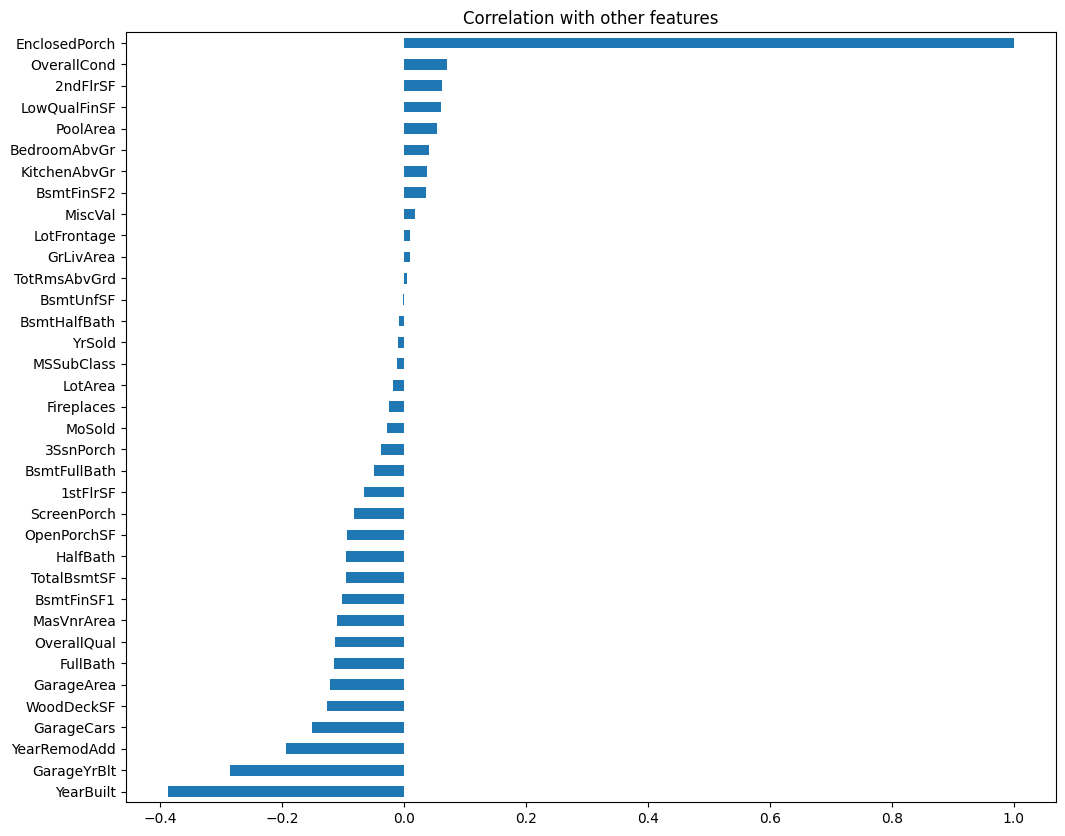

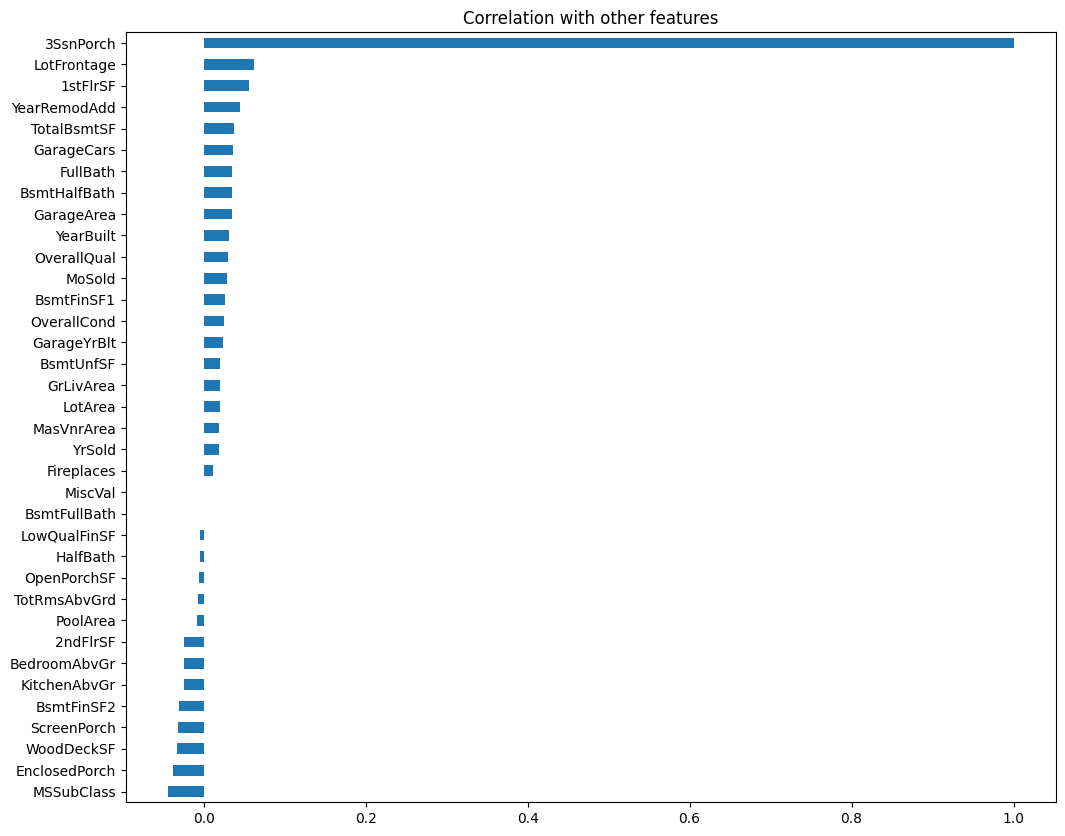

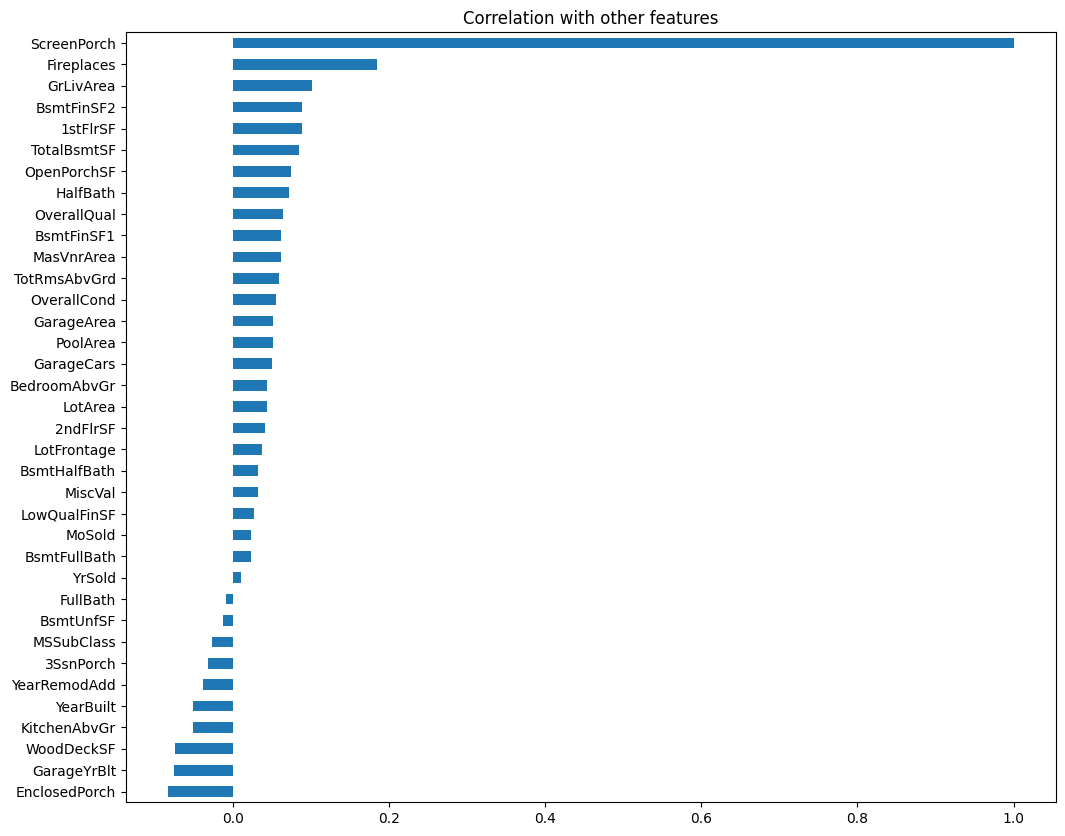

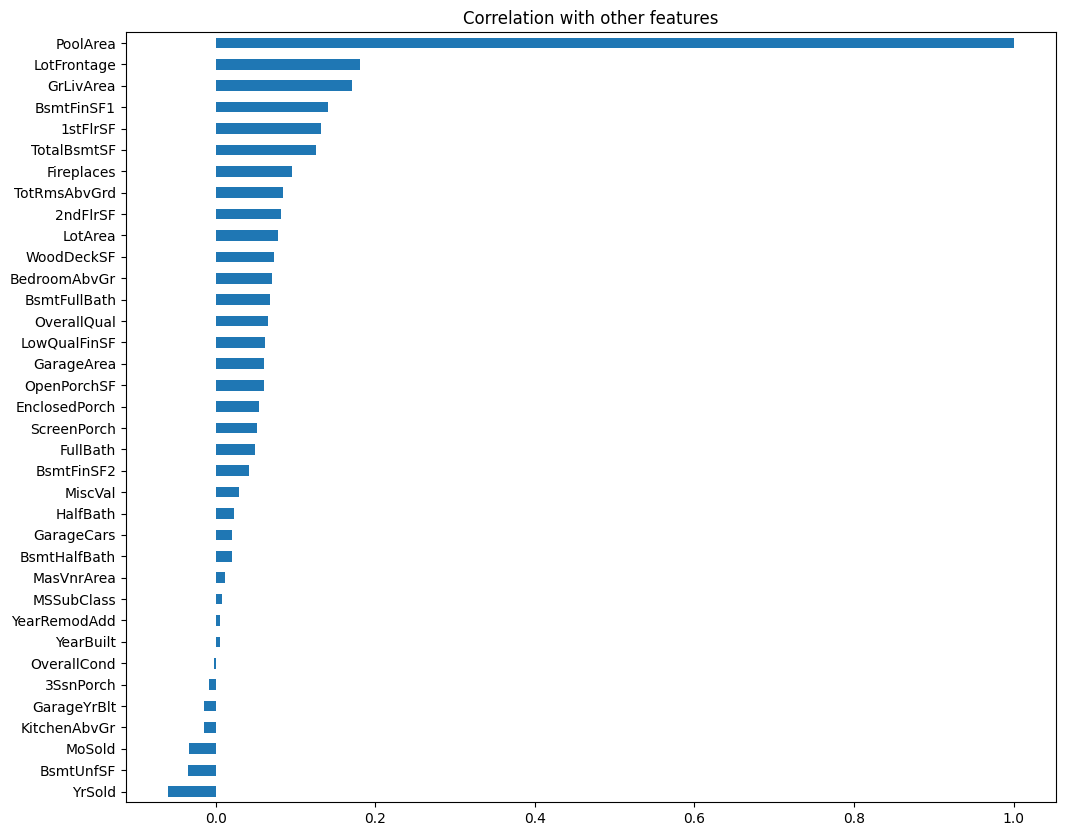

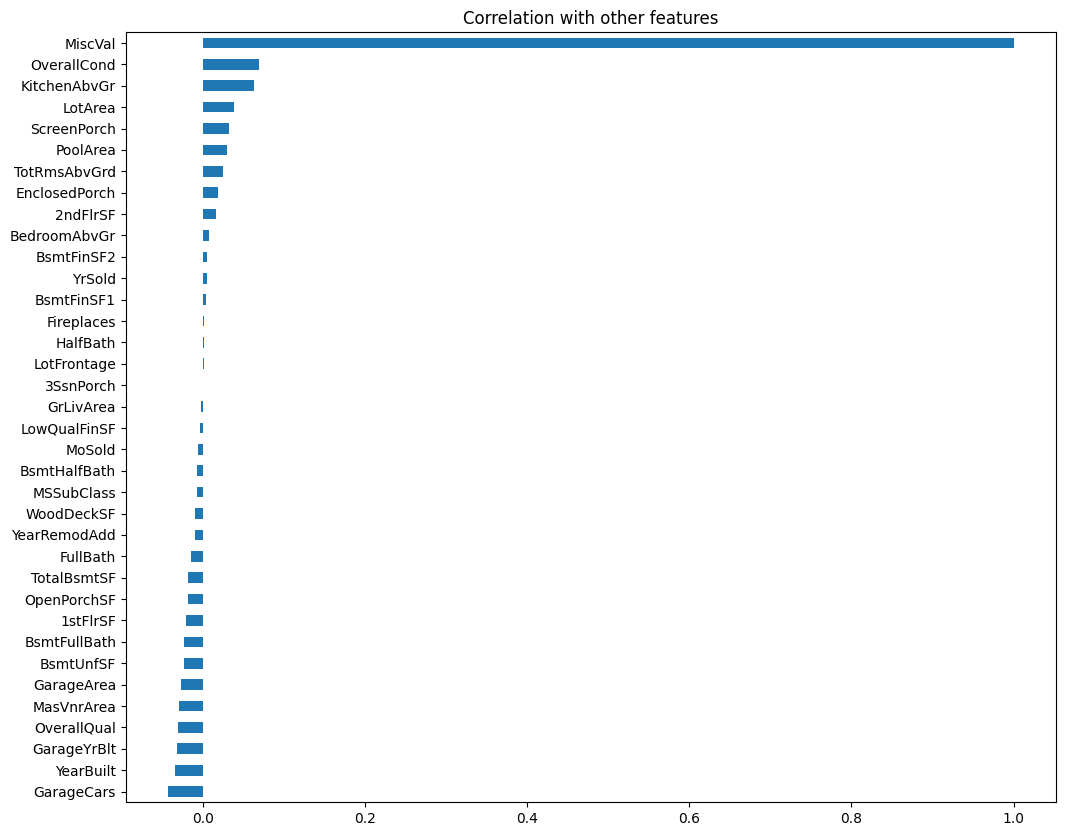

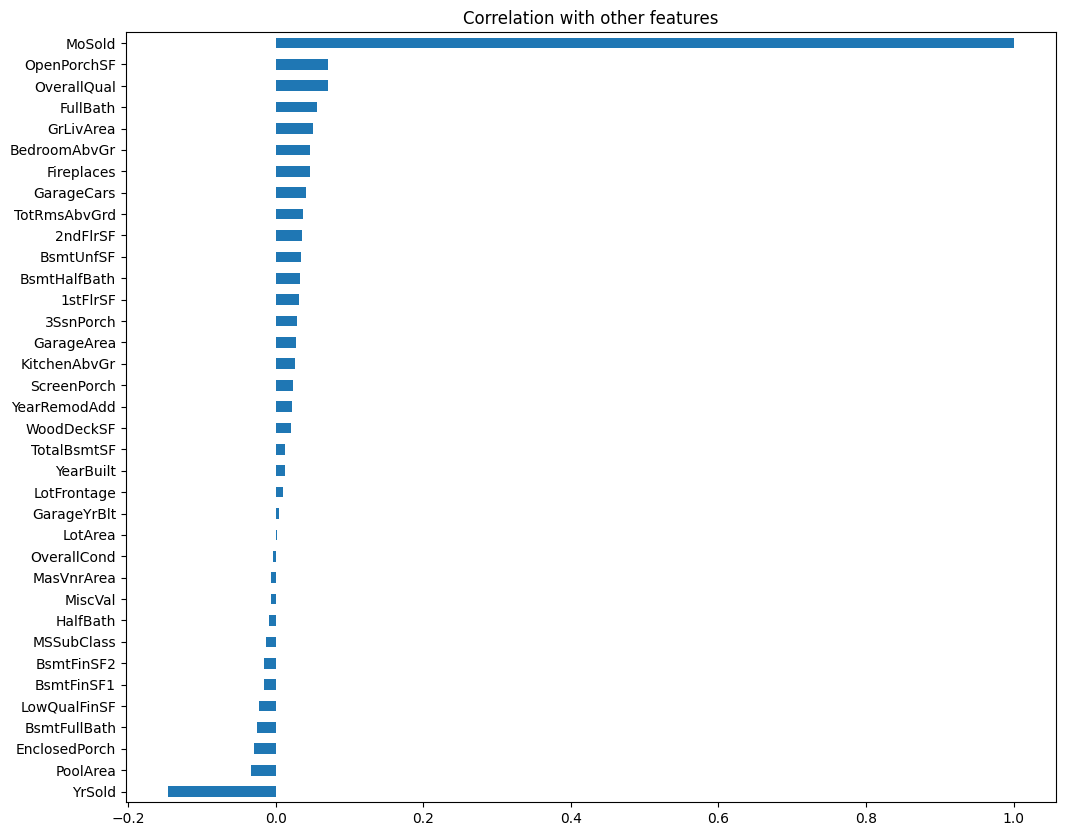

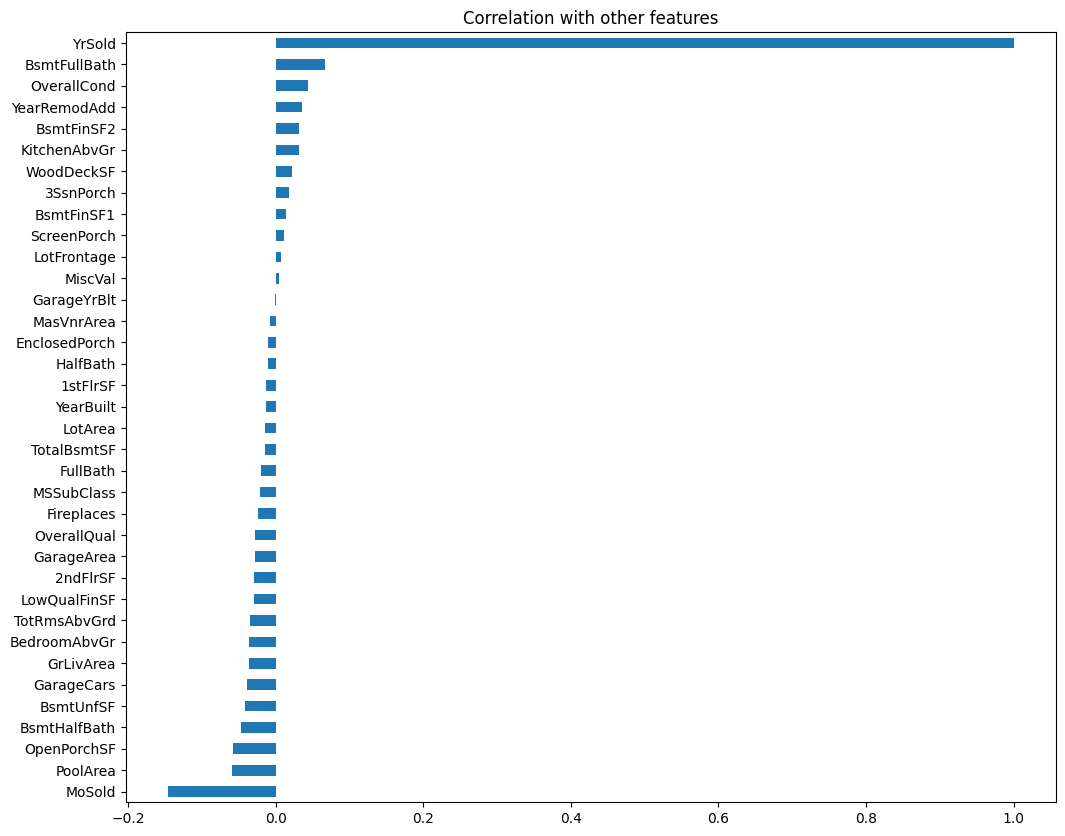

In [10]:
corrn_train = df_train[numeric_col[:-1]].corr()
for i in [-7, -6, -5, -4, -3, -2, -1]:
    corrn_train.iloc[:,i].sort_values(ascending=True).plot(kind='barh', figsize=(12,10), title='Correlation with other features')
    plt.show()

train

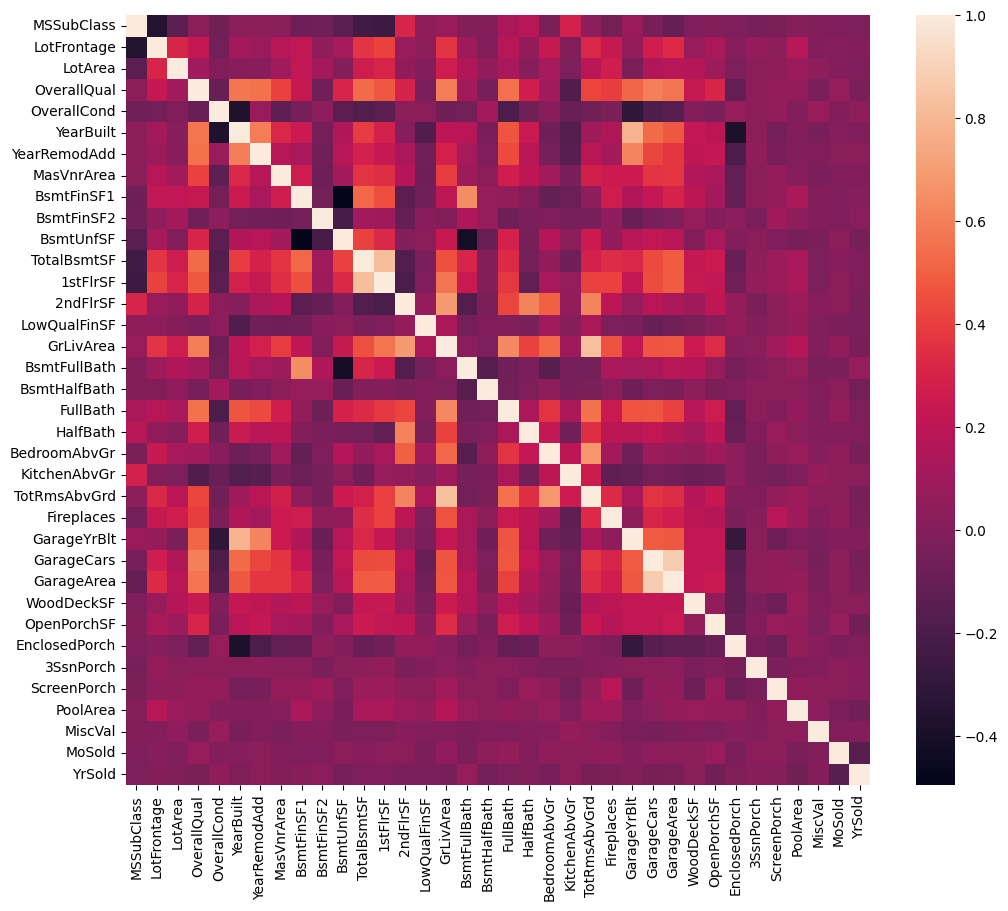

In [11]:
corrn_train = df_train[numeric_col[:-1]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corrn_train)

plt.savefig(fname       = f"eda/data_{DATA_TYPE}/numerical_feature/heatmap_train.png", 
            dpi         = 300, 
            bbox_inches = 'tight')

test

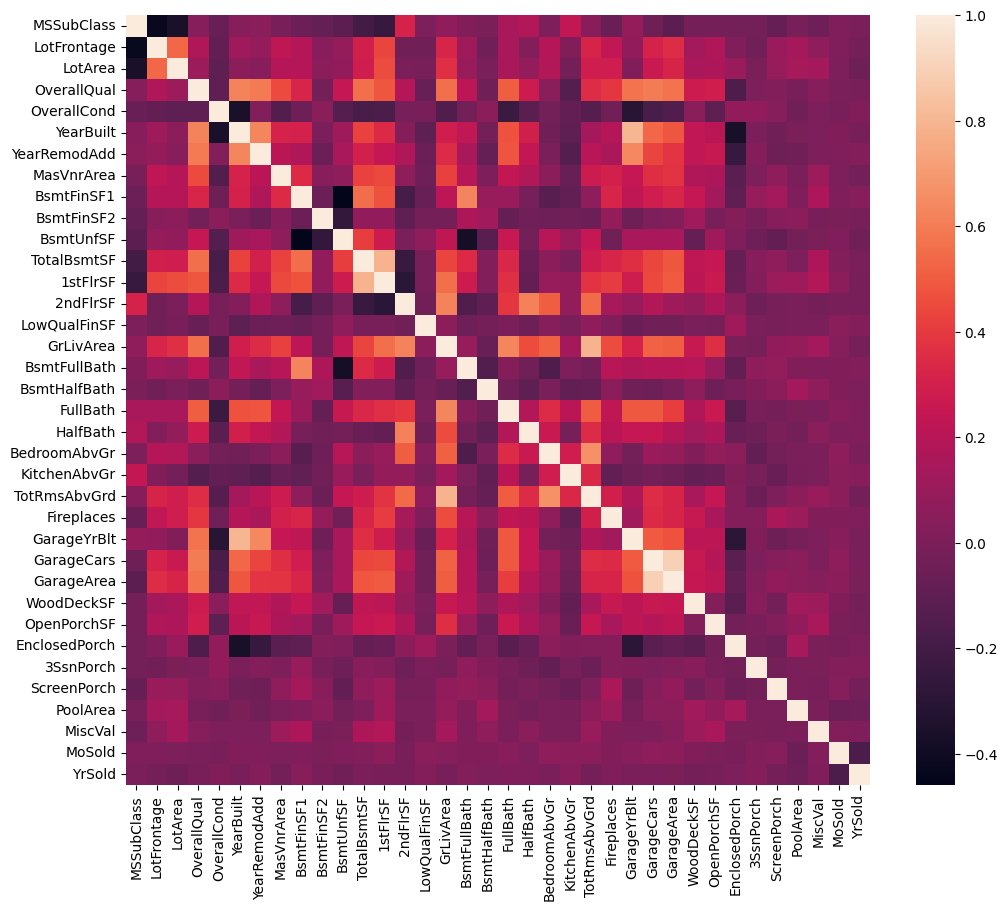

In [12]:
corrn_test = df_test[numeric_col[:-1]].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corrn_test)

plt.savefig(fname       = f"eda/data_{DATA_TYPE}/numerical_feature/heatmap_test.png", 
            dpi         = 300, 
            bbox_inches = 'tight')

### 2.2.2. Pairplot

train

In [13]:
# sns.pairplot(df_train[numeric_col])

test

In [14]:
# sns.pairplot(df_test[numeric_col[:-1]])

### 2.2.3. Boxplot

train

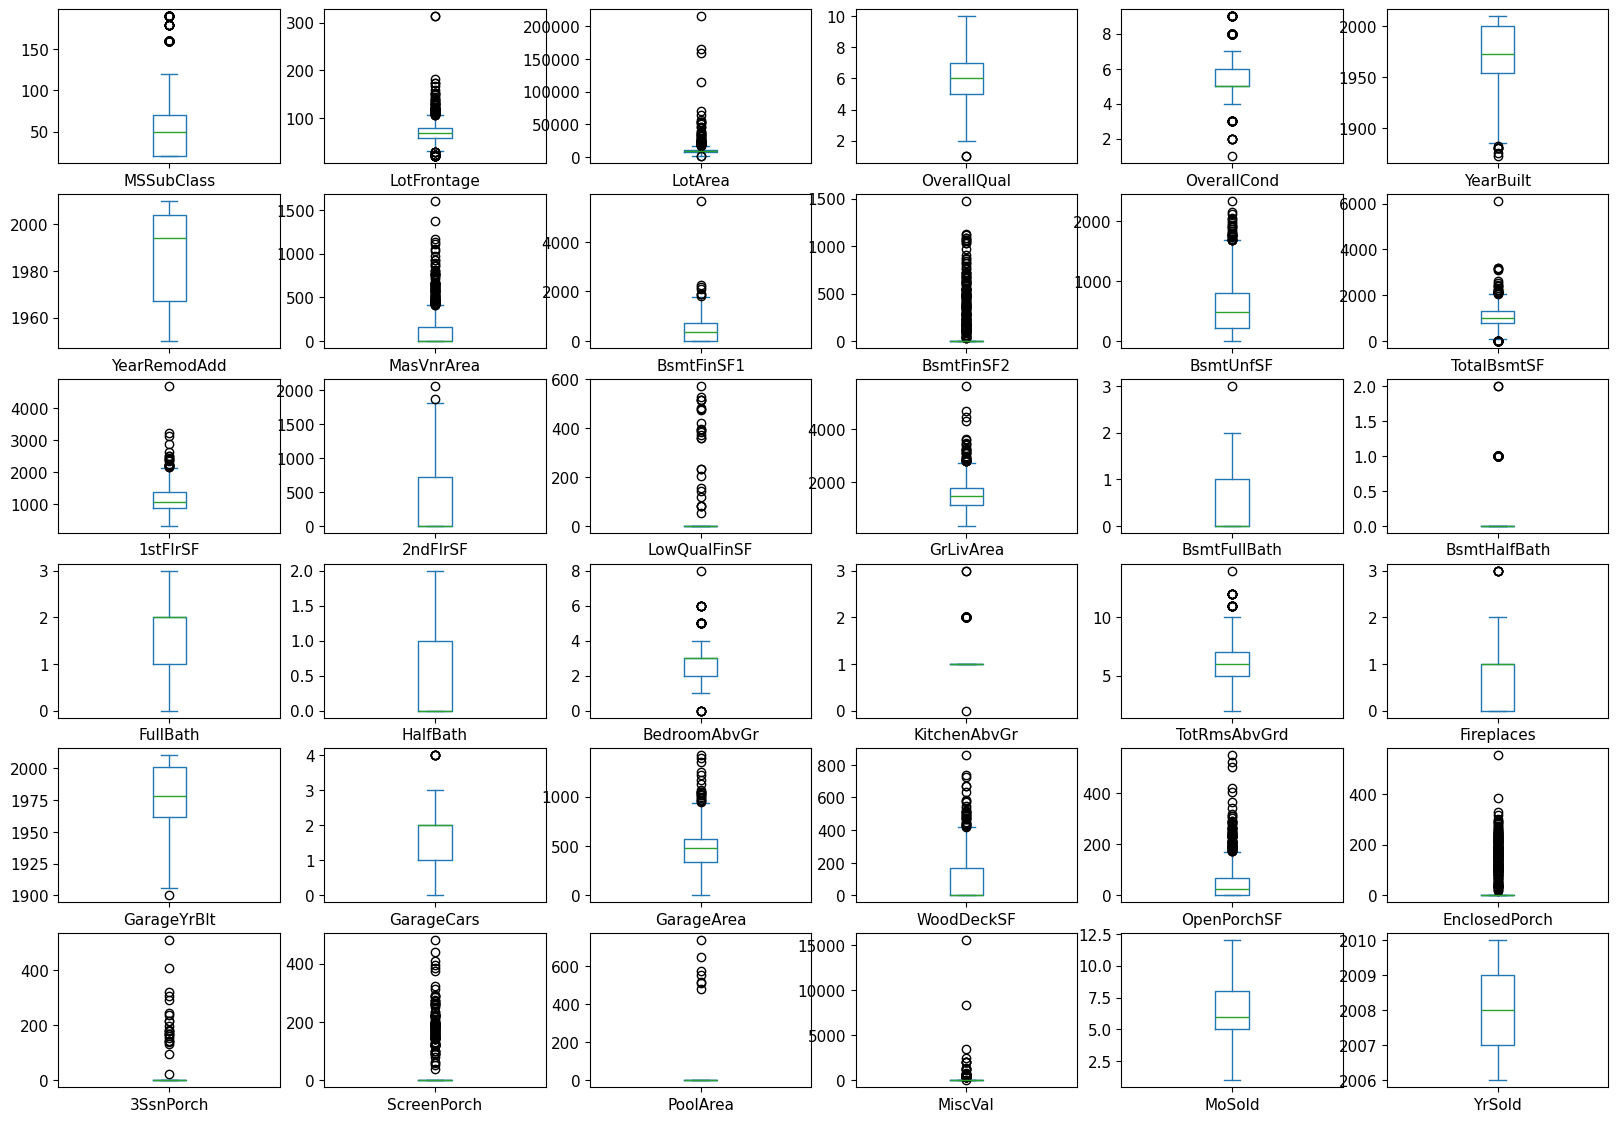

In [15]:
df_train[numeric_col[:-1]].plot(kind     = "box",
                                subplots = True,
                                layout   = (6, 6), 
                                figsize  = (20, 14),
                                fontsize = 11,
                                sharex   = False,
                                sharey   = False)

plt.savefig(fname       = f"eda/data_{DATA_TYPE}/numerical_feature/boxplot_train.png", 
            dpi         = 300, 
            bbox_inches = 'tight')

test

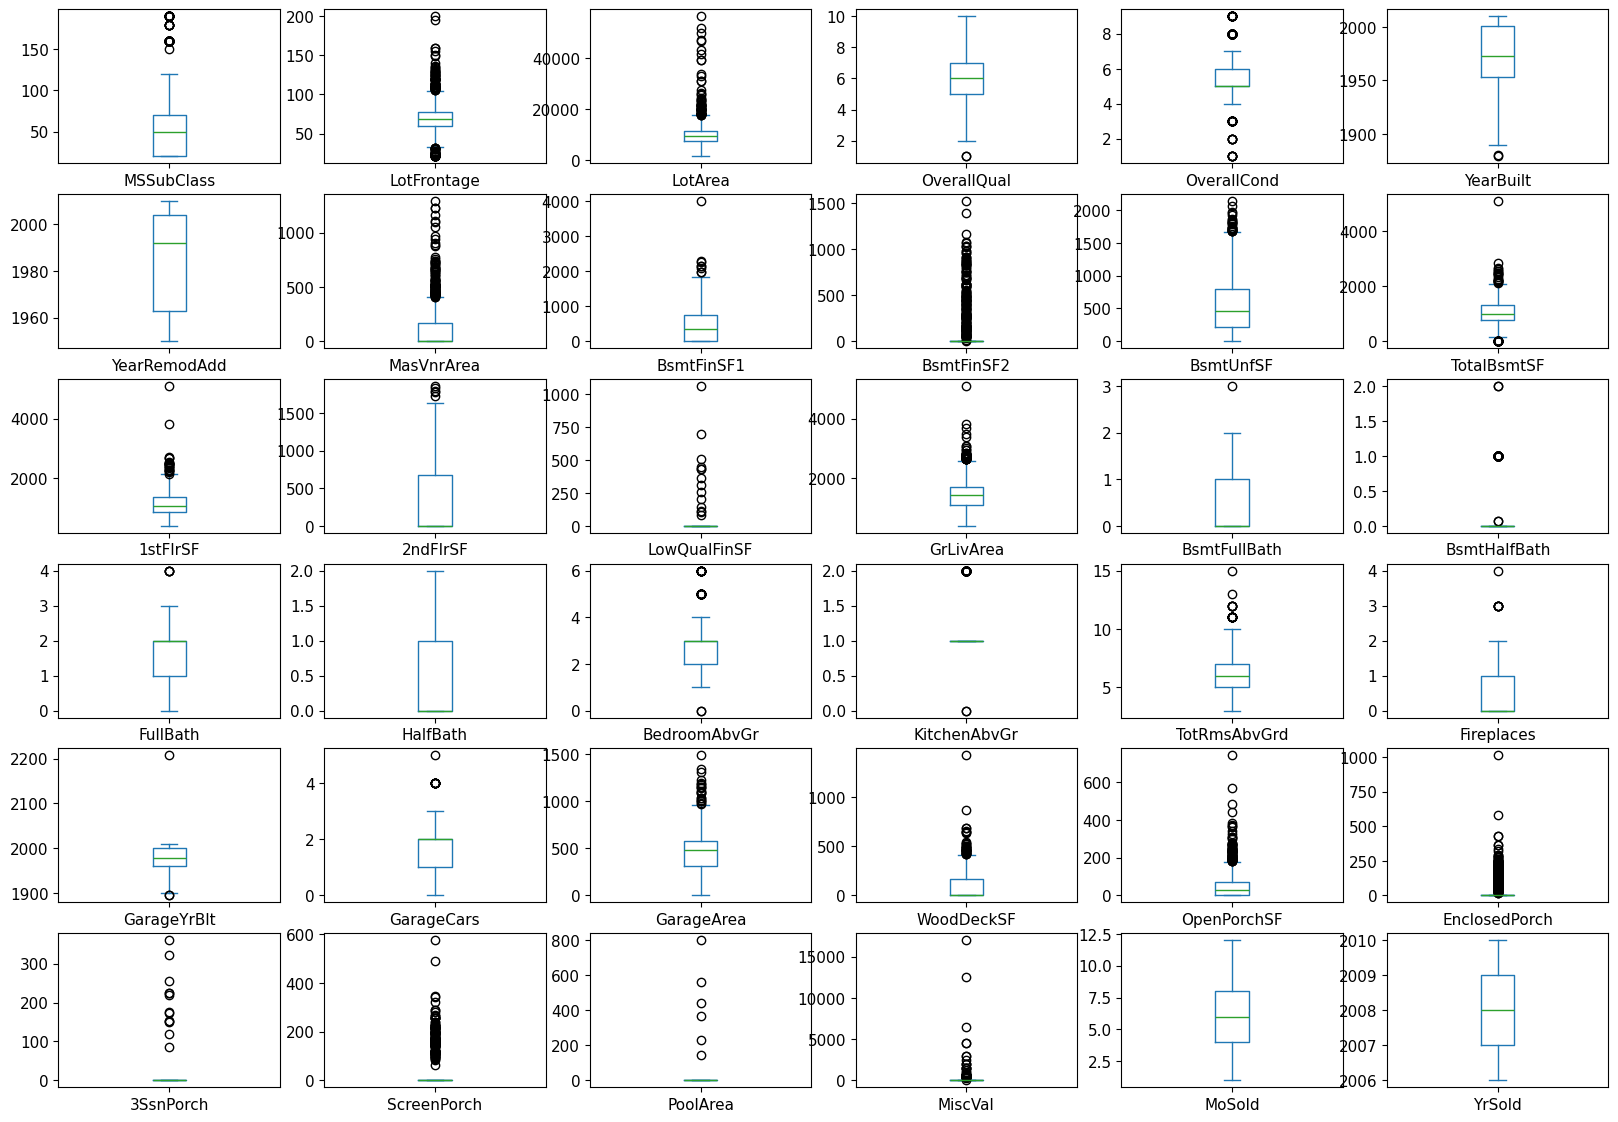

In [16]:
df_test[numeric_col[:-1]].plot(kind     = "box",
                               subplots = True,
                               layout   = (6, 6), 
                               figsize  = (20, 14),
                               fontsize = 11,
                               sharex   = False,
                               sharey   = False)

plt.savefig(fname       = f"eda/data_{DATA_TYPE}/numerical_feature/boxplot_test.png", 
            dpi         = 300, 
            bbox_inches = 'tight')

## 2.3. Categorical feature

In [17]:
categorical_col = df_train.select_dtypes(include=['object']).columns

### 2.3.1. Barplot + Boxplot

In [18]:
os.makedirs(exist_ok = True,
            name     = f"eda/data_{DATA_TYPE}/categorical_feature/bar_box/")

train

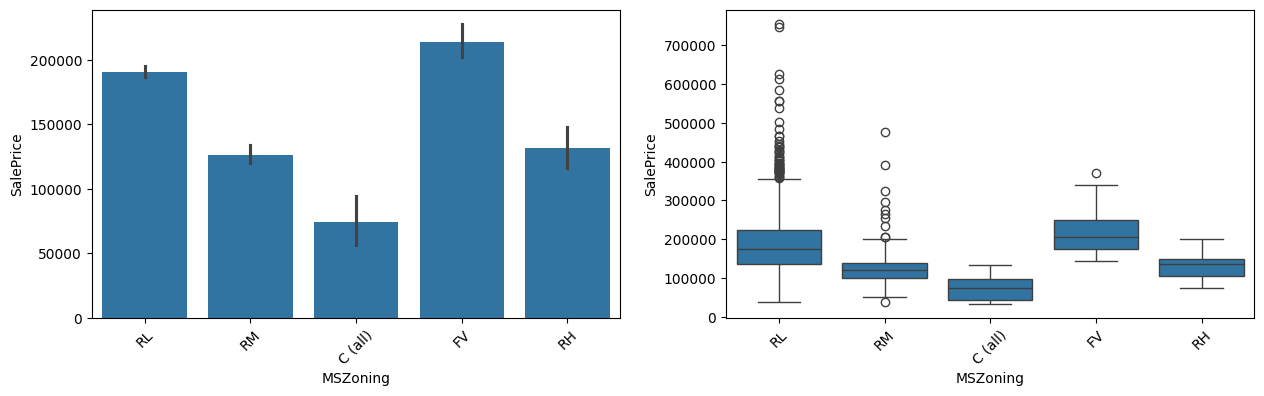

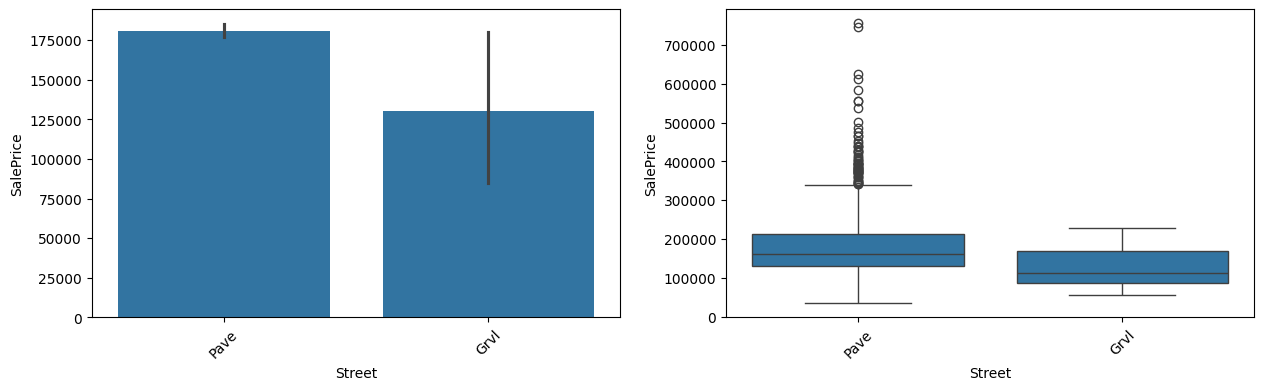

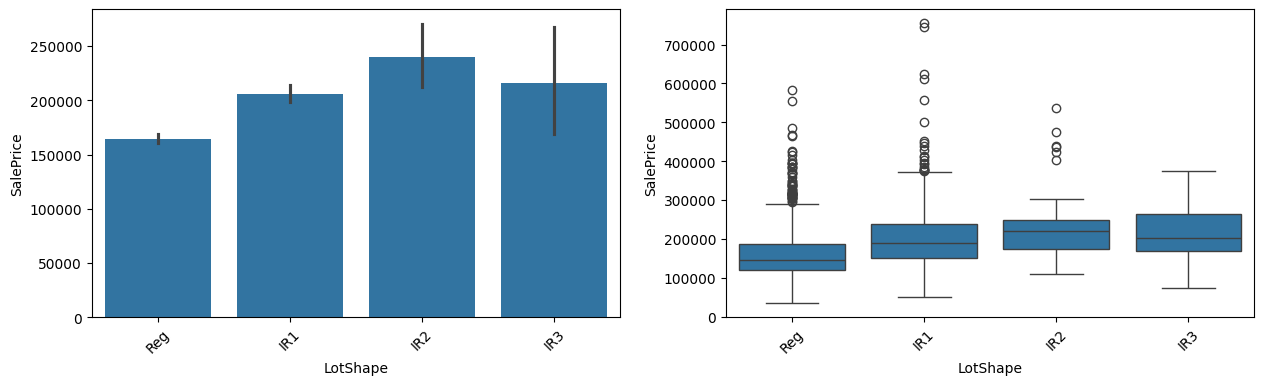

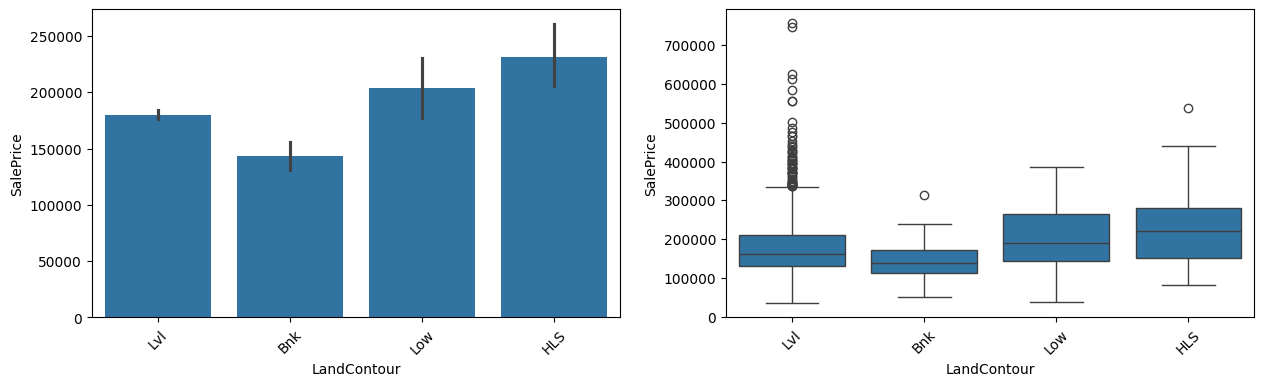

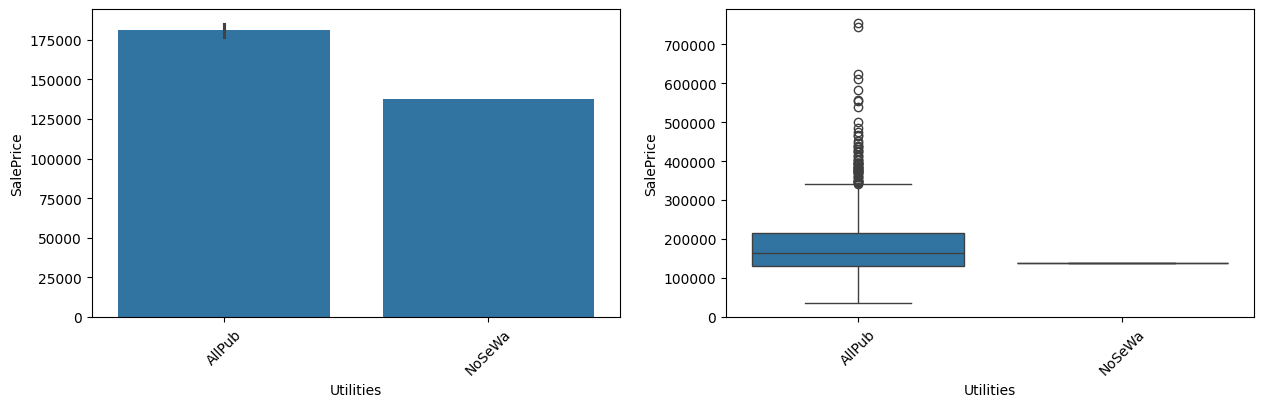

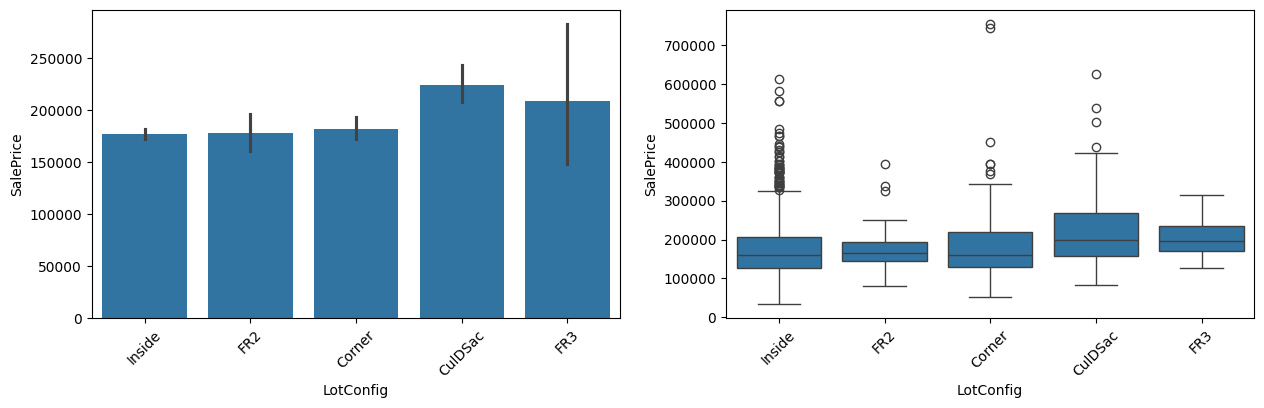

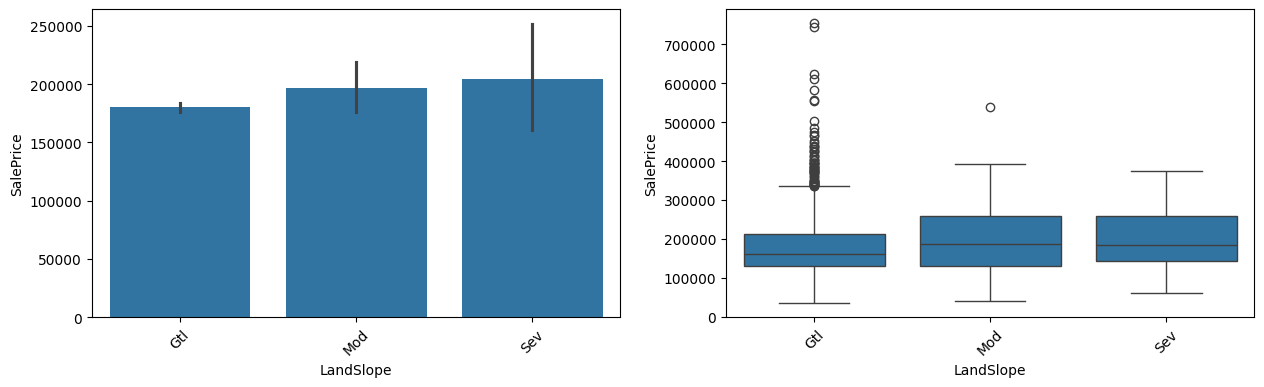

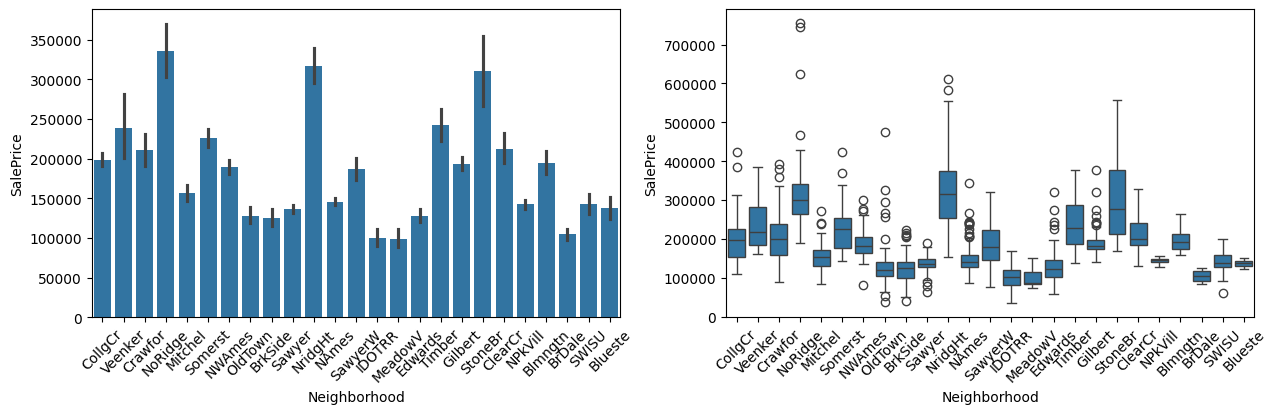

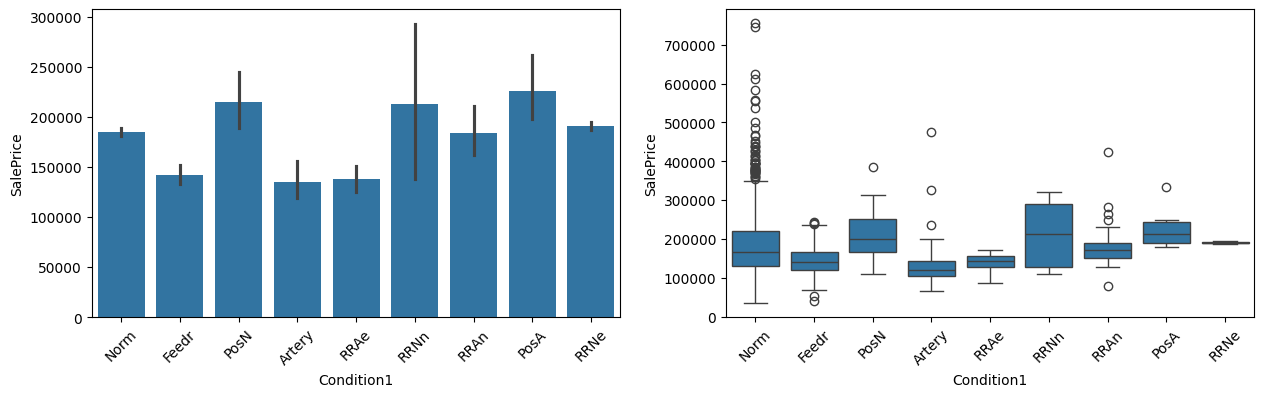

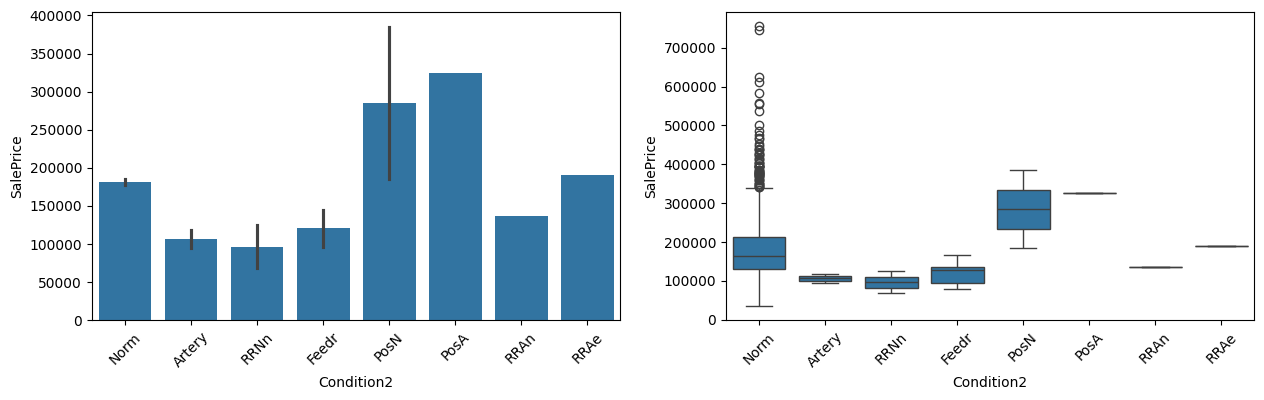

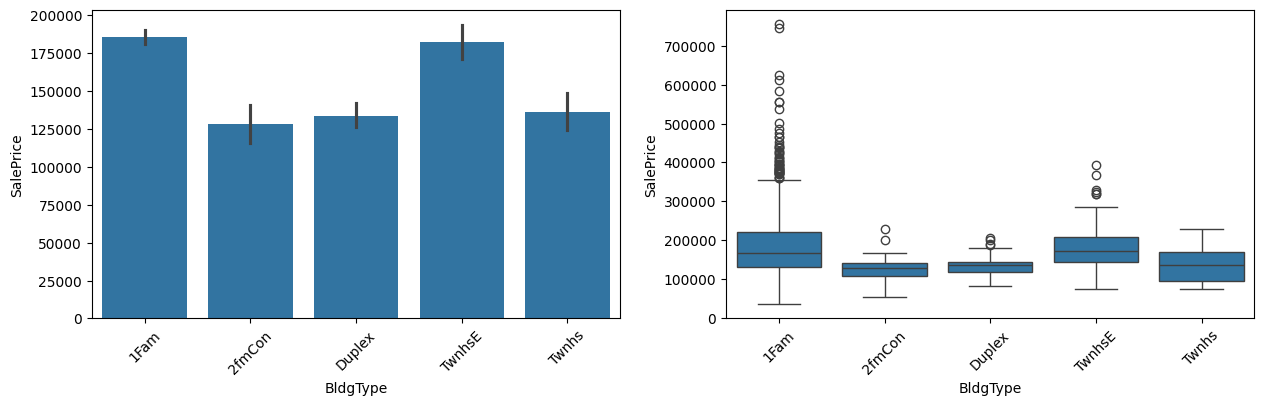

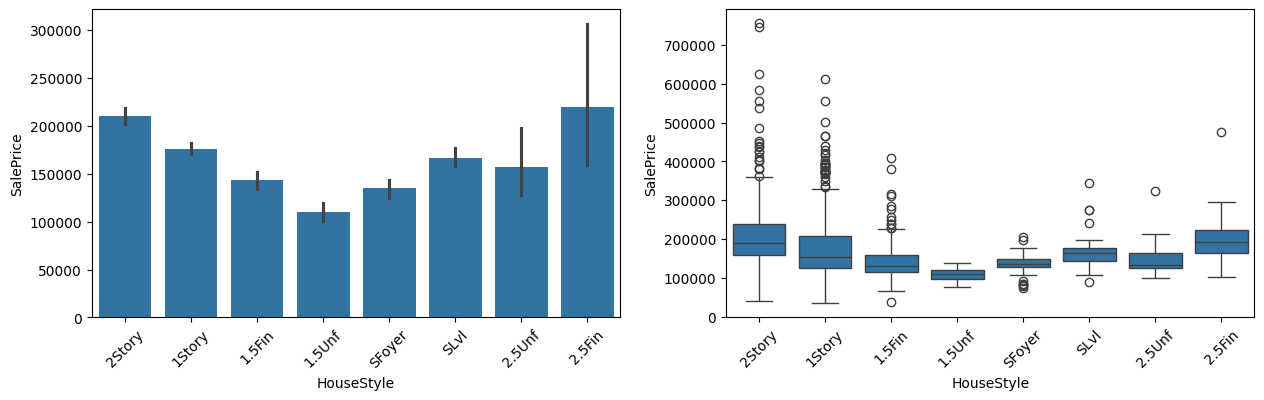

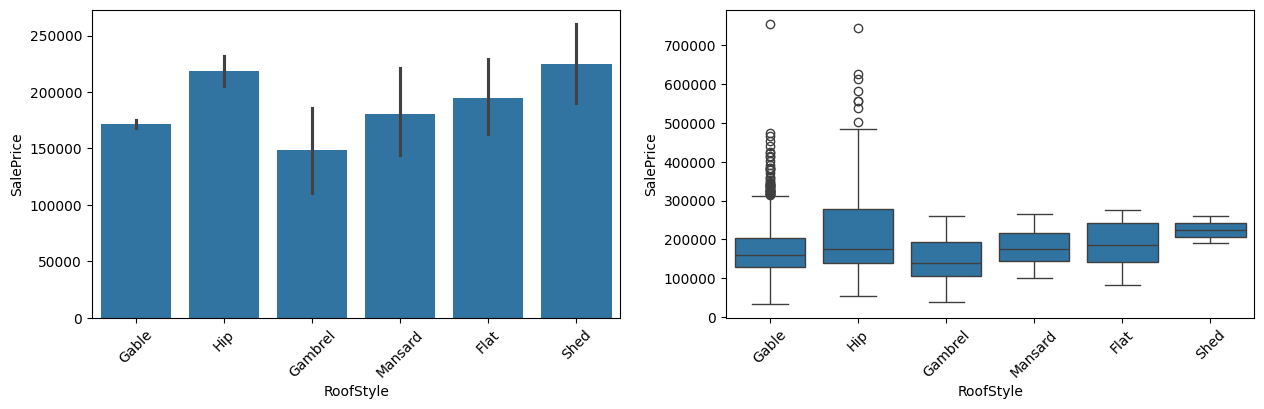

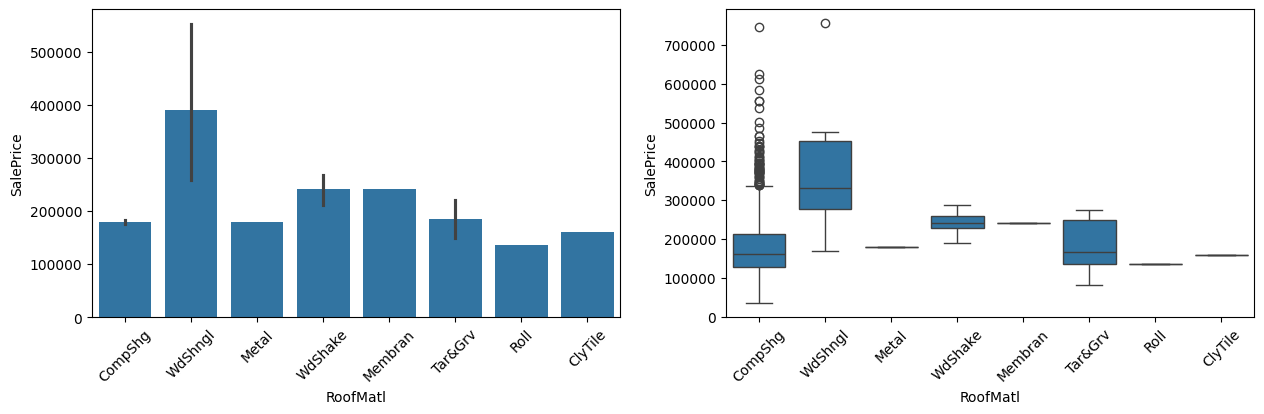

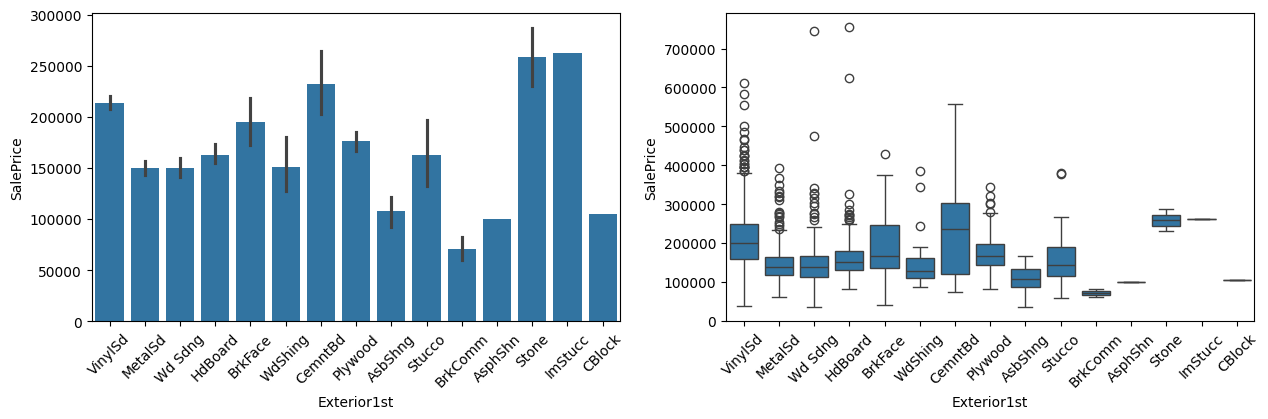

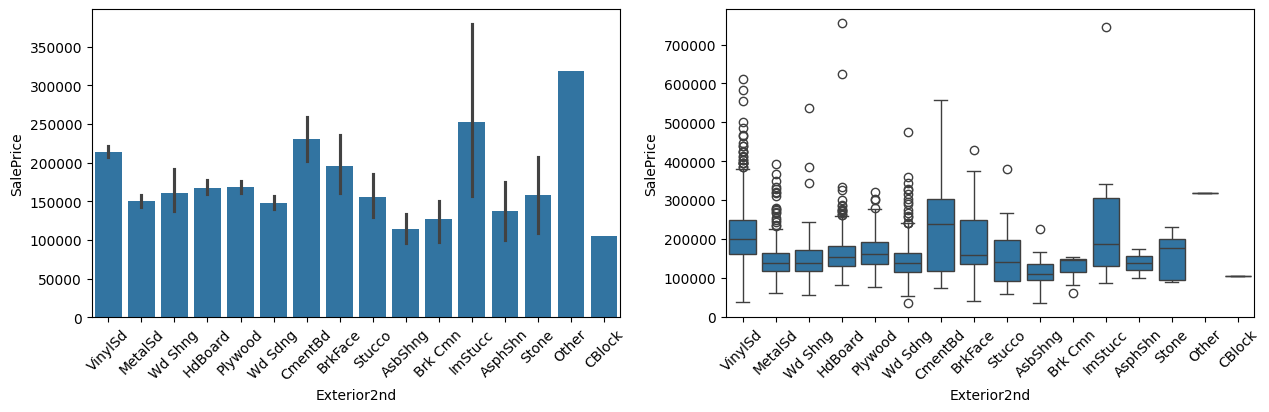

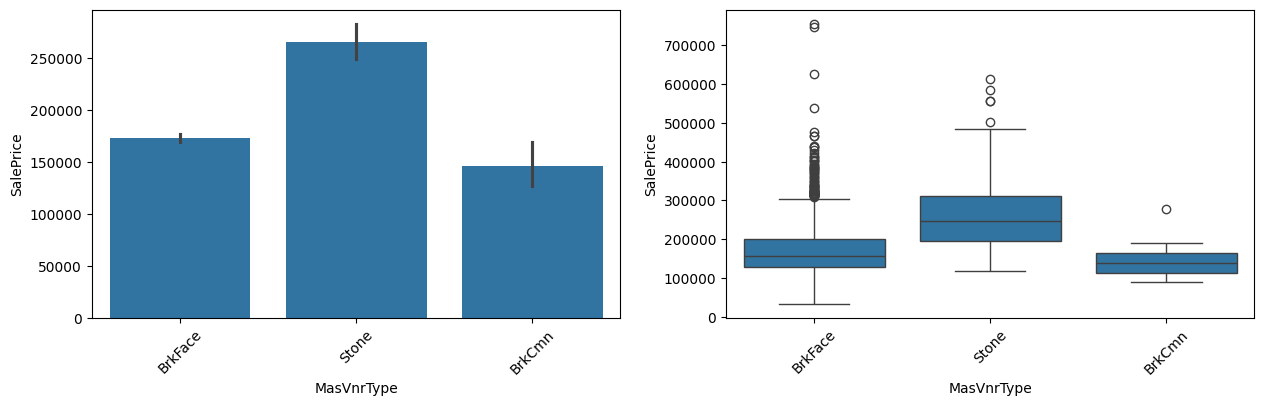

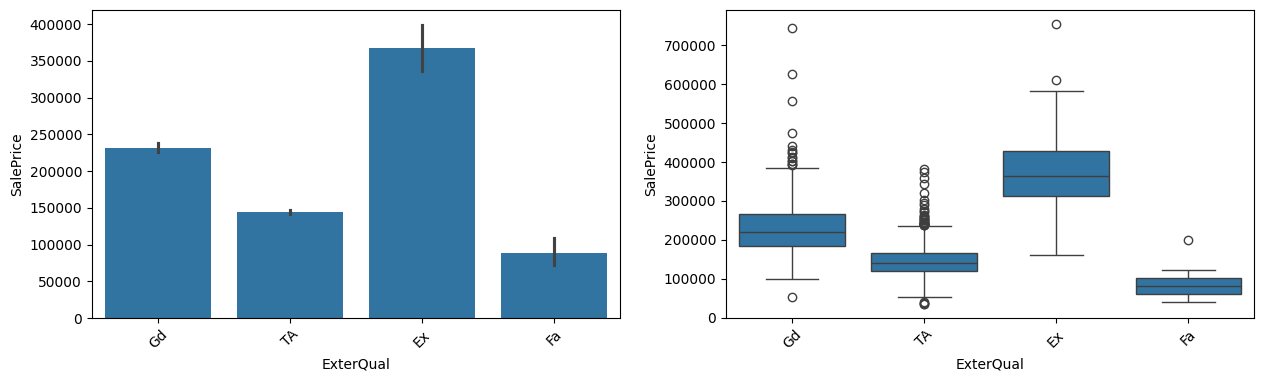

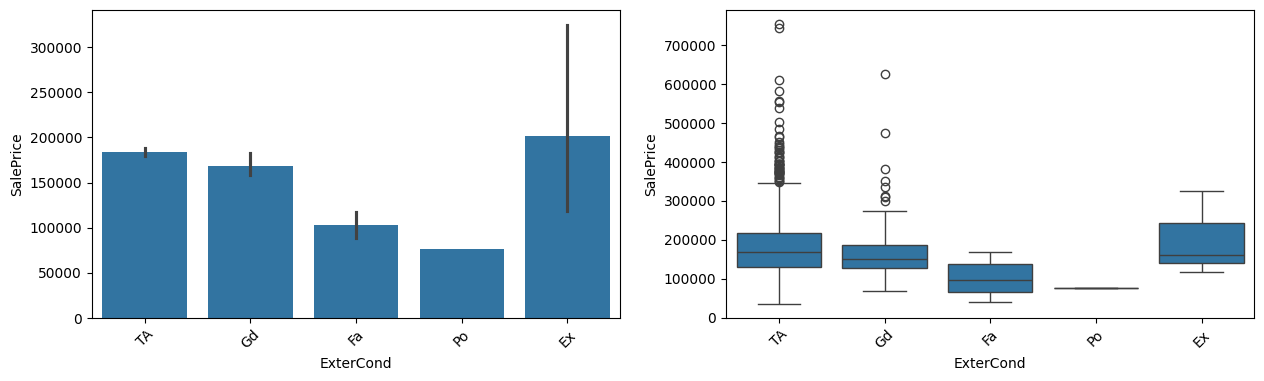

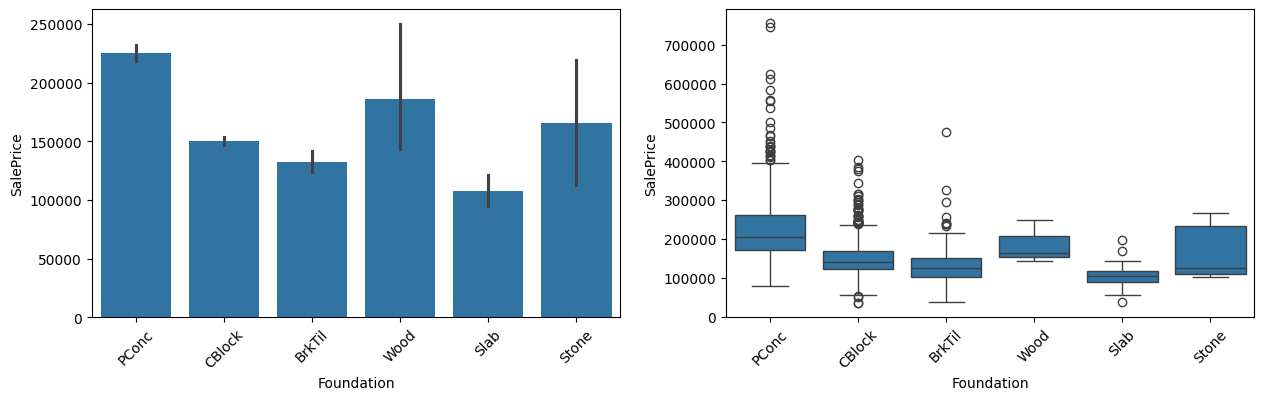

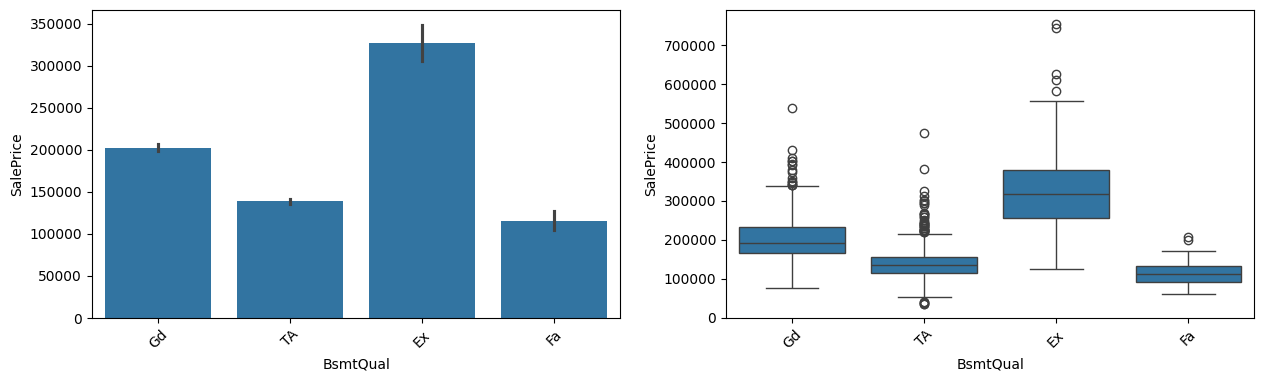

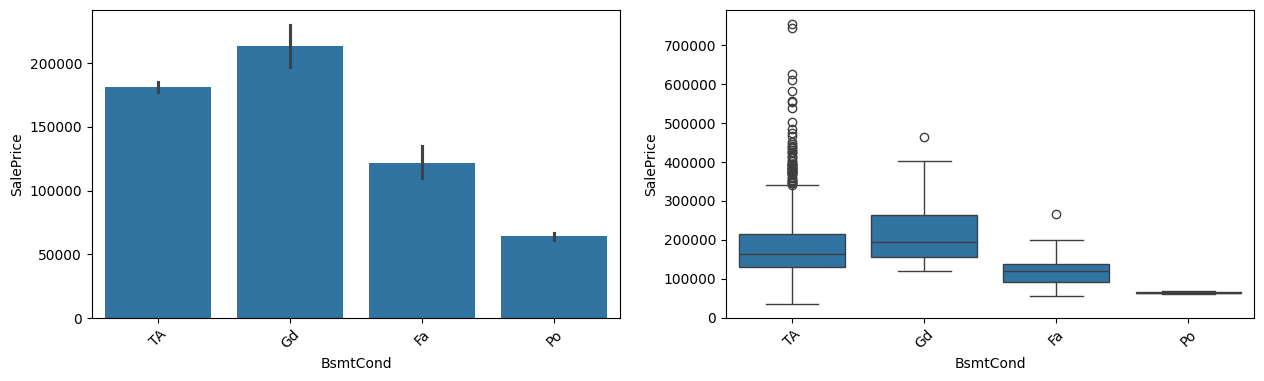

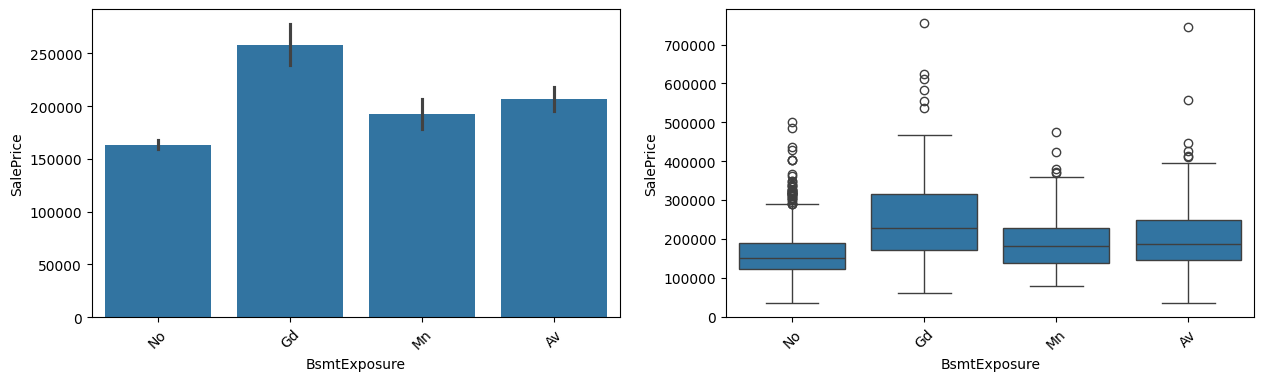

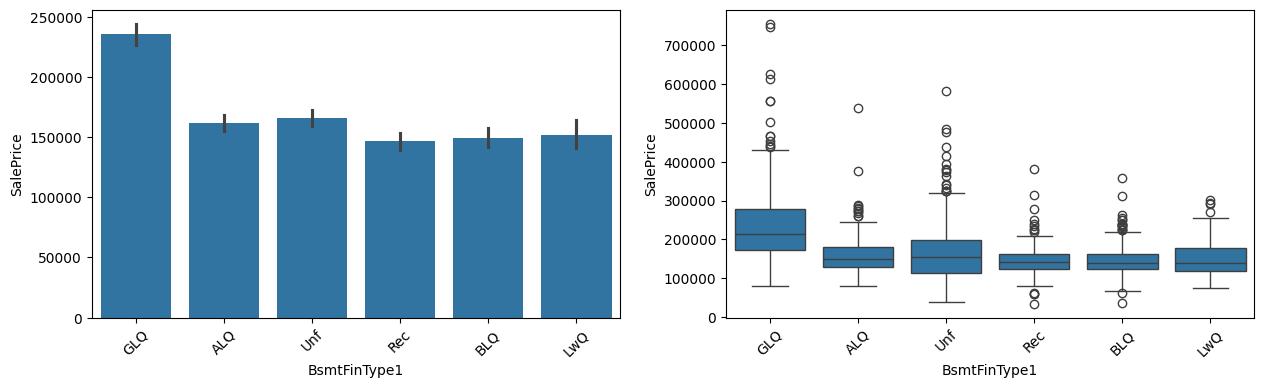

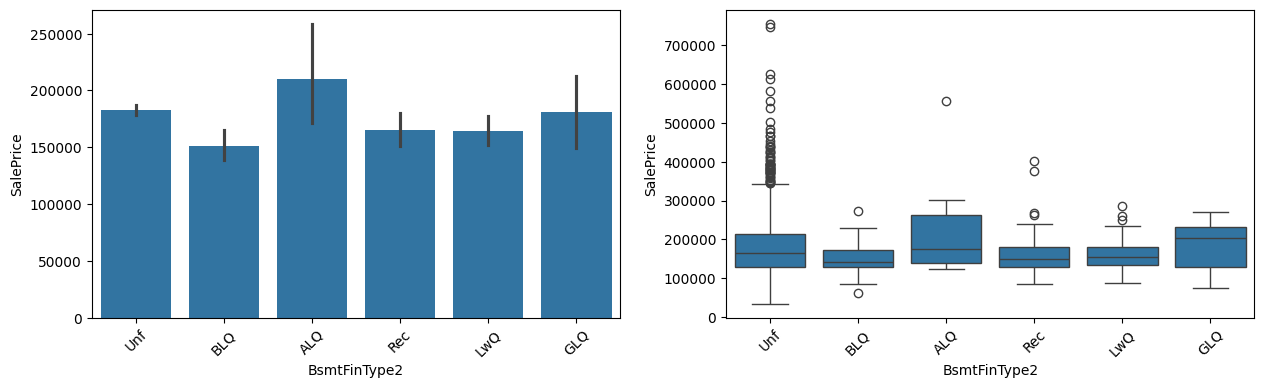

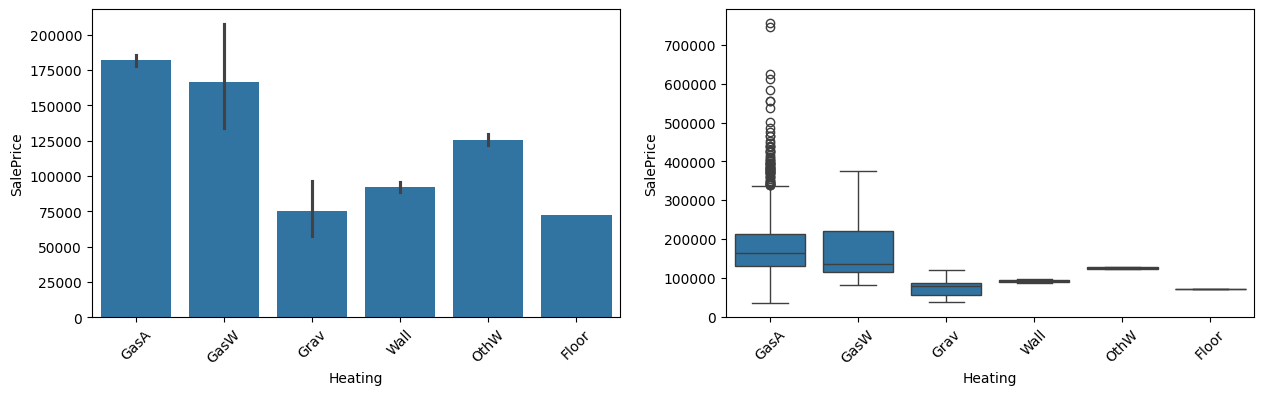

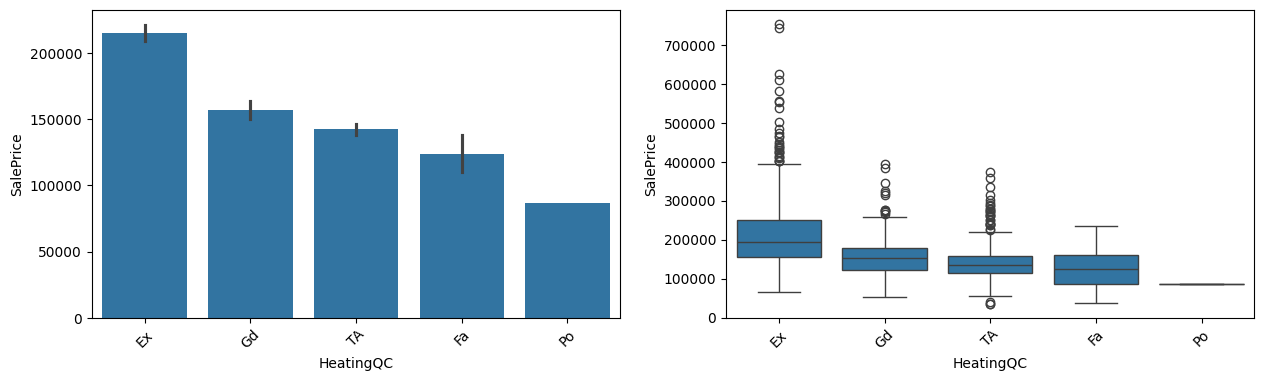

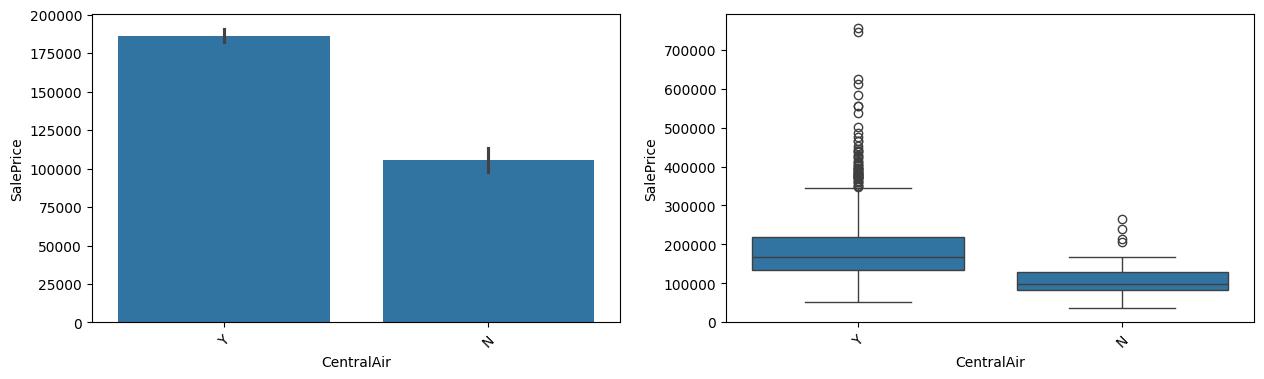

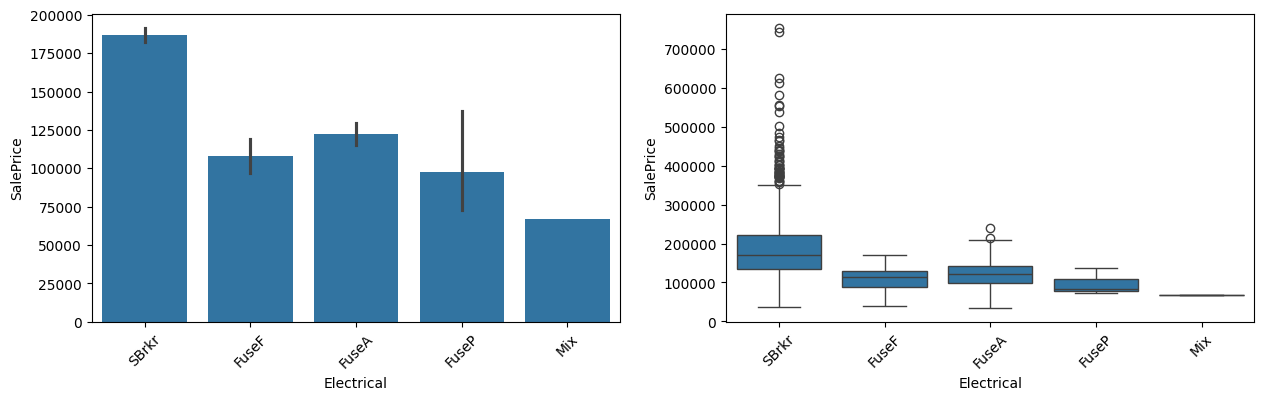

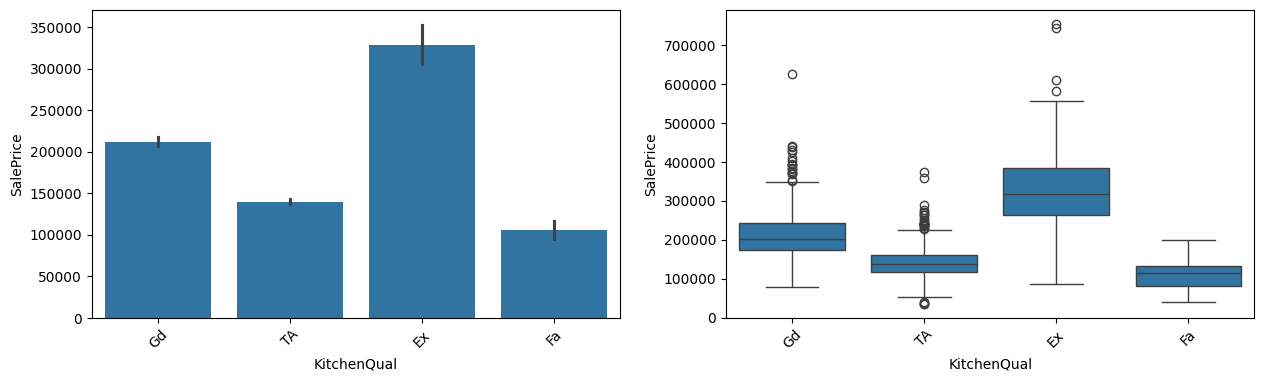

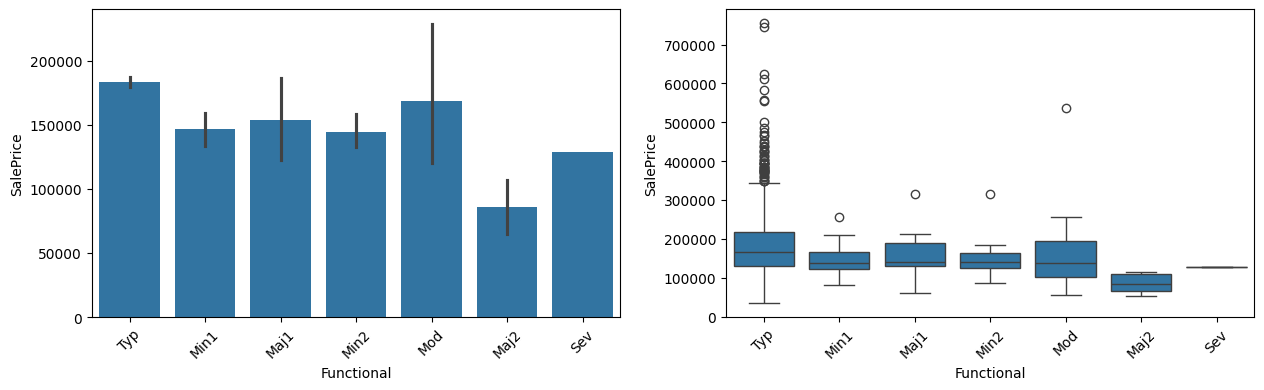

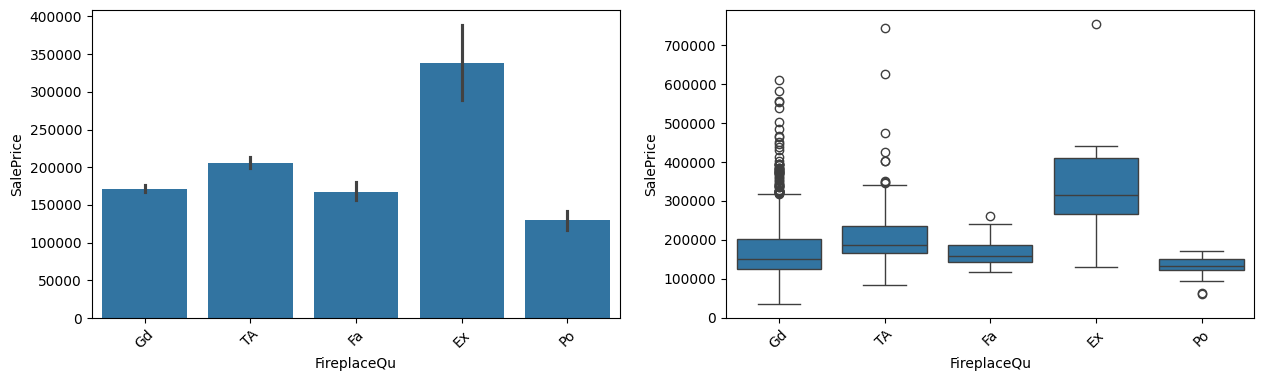

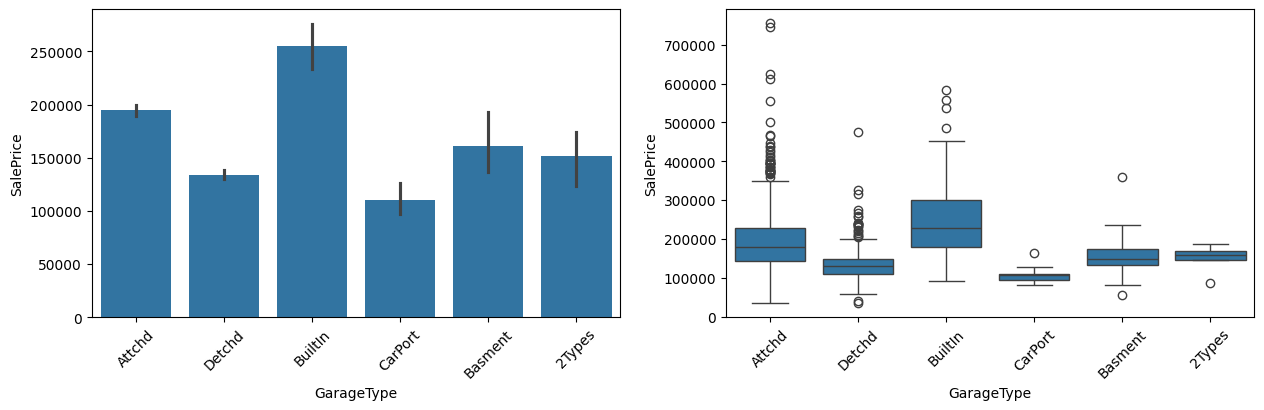

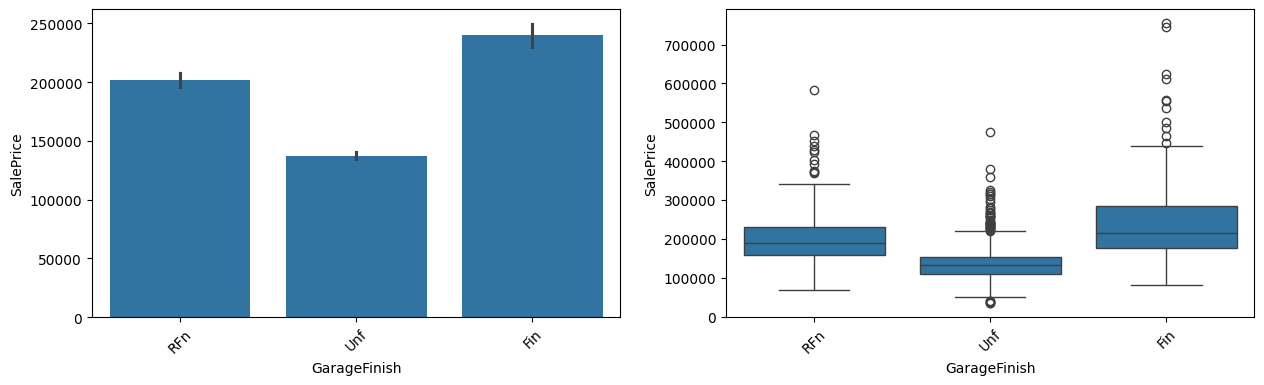

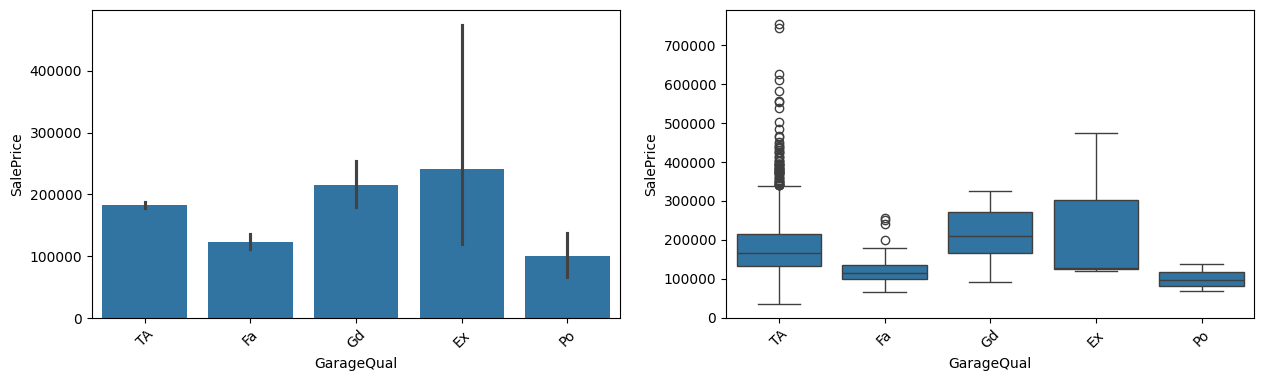

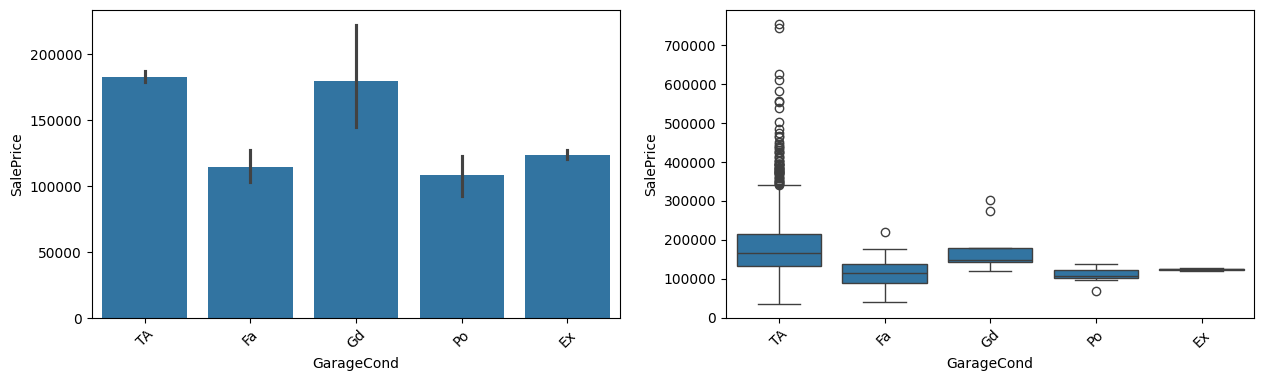

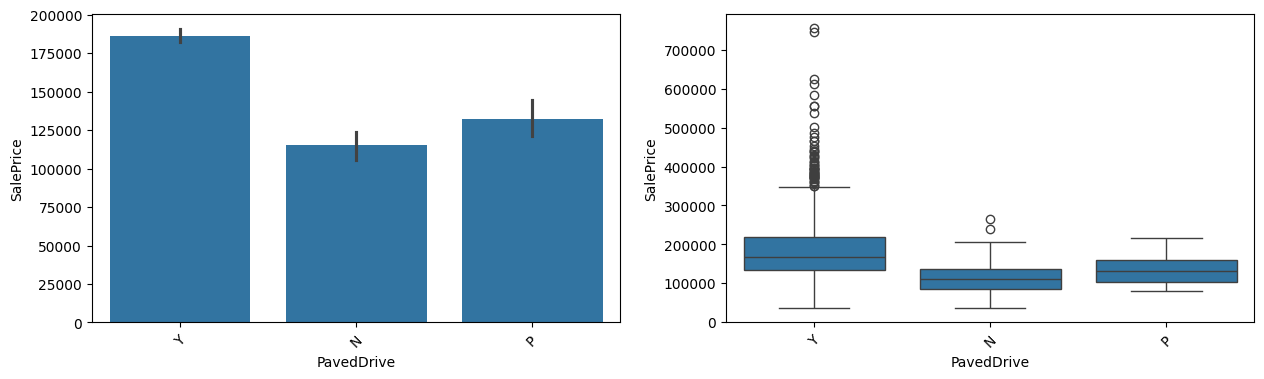

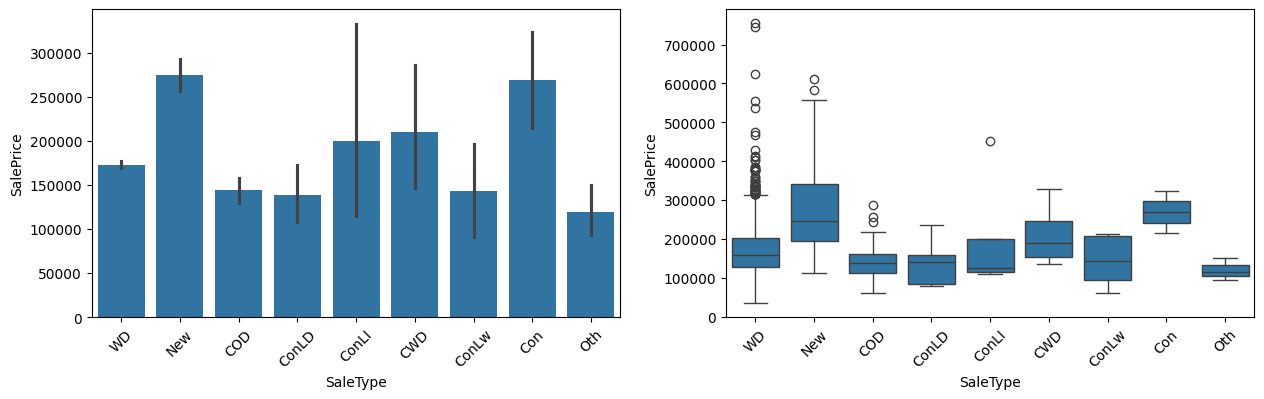

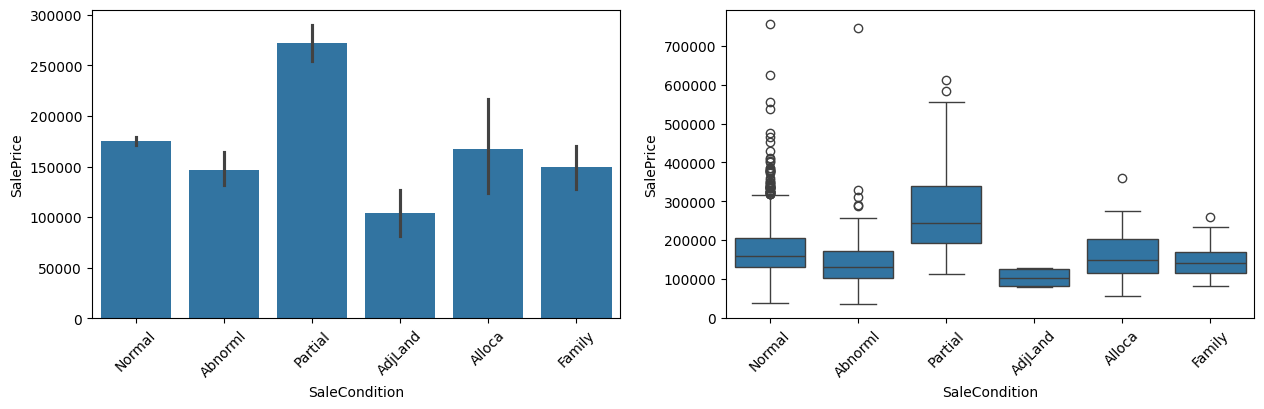

In [19]:
for i in categorical_col:
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    sns.barplot(df_train, y="SalePrice", x = i, ax=ax[0])
    sns.boxplot(df_train, y="SalePrice", x = i, ax=ax[1])
    
    ax[0].tick_params(axis='x', rotation=45)
    ax[1].tick_params(axis='x', rotation=45)
    
    plt.savefig(fname       = f"eda/data_{DATA_TYPE}/categorical_feature/bar_box/{i}_vs_SalePrice.png", 
                dpi         = 300, 
                bbox_inches = 'tight')
    plt.show()

test